# 01 — Eksplorasi Data

Notebook ini menganalisis dataset dengan **3 fitur**: `accel_stddev`, `gyro_stddev`, dan `bpm`.

**Prasyarat:** Jalankan `data_collection.py` atau `collect_participants.py` terlebih dahulu.

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from config import DATASET_PATH, CLASSES, FEATURES, TARGET, SESSION_DURATION_SEC
from utils  import load_and_clean_dataset, impute_bpm, class_distribution, get_logger

logger = get_logger('notebook_01')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (13, 5)
COLORS = ['#4C72B0', '#DD8452', '#55A868']
print('Library siap. Fitur:', FEATURES)

Library siap. Fitur: ['accel_stddev', 'gyro_stddev', 'bpm_filled']


## 1. Muat & Bersihkan Dataset

In [2]:
df_raw = load_and_clean_dataset(DATASET_PATH)
print(f'Shape raw: {df_raw.shape}')
print(f'Kolom    : {df_raw.columns.tolist()}')
print(f'\nDistribusi kelas:\n{df_raw[TARGET].value_counts()}')
df_raw.head(8)

Shape raw: (1564, 6)
Kolom    : ['accel_stddev', 'gyro_stddev', 'bpm', 'activity', 'participant_id', 'received_at']

Distribusi kelas:
activity
DUDUK       886
BERJALAN    446
BERLARI     232
Name: count, dtype: int64


,accel_stddev,gyro_stddev,bpm,activity,participant_id,received_at
0,0.004814,0.0522,0,DUDUK,data_collection_DUDUK,2026-04-12T19:38:00.152797
1,0.004814,0.0522,0,DUDUK,data_collection_DUDUK,2026-04-12T19:38:00.152797
2,0.004938,0.0545,0,DUDUK,data_collection_DUDUK,2026-04-12T19:38:02.162900
3,0.004938,0.0545,0,DUDUK,data_collection_DUDUK,2026-04-12T19:38:02.164238
4,0.006231,0.0494,0,DUDUK,data_collection_DUDUK,2026-04-12T19:38:04.162725
5,0.006231,0.0494,0,DUDUK,data_collection_DUDUK,2026-04-12T19:38:04.162725
6,0.007409,0.0336,0,DUDUK,data_collection_DUDUK,2026-04-12T19:38:06.171475
7,0.007409,0.0336,0,DUDUK,data_collection_DUDUK,2026-04-12T19:38:06.172649


## 2. Imputasi BPM = 0

Sensor pulse sering membaca 0 saat sinyal lemah. Nilai 0 diisi dengan median BPM per kelas.

In [3]:
# Tampilkan statistik BPM sebelum imputasi
print('=== BPM sebelum imputasi ===')
print(f'Nilai 0 (tidak terbaca): {(df_raw["bpm"]==0).sum()} dari {len(df_raw)} ({(df_raw["bpm"]==0).mean()*100:.1f}%)')
print(f'Range BPM valid: {df_raw[df_raw["bpm"]>0]["bpm"].min()} – {df_raw[df_raw["bpm"]>0]["bpm"].max()}')

# Imputasi
df, bpm_medians = impute_bpm(df_raw, fit=True)

print('\n=== Setelah imputasi (kolom bpm_filled) ===')
print(df[['accel_stddev','gyro_stddev','bpm','bpm_filled',TARGET]].describe().round(3))

=== BPM sebelum imputasi ===
Nilai 0 (tidak terbaca): 38 dari 1564 (2.4%)
Range BPM valid: 32 – 186
BPM Median per kelas (untuk imputasi):
  DUDUK: 70 bpm
  BERJALAN: 117 bpm
  BERLARI: 152 bpm
  _global: 76 bpm

=== Setelah imputasi (kolom bpm_filled) ===
       accel_stddev  gyro_stddev       bpm  bpm_filled
count      1564.000     1564.000  1564.000    1564.000
mean          0.057        9.184    93.269      95.517
std           0.100       12.959    37.796      35.084
min           0.003        0.033     0.000      32.000
25%           0.006        0.579    69.000      69.000
50%           0.009        1.742    75.000      76.000
75%           0.049       12.076   122.000     123.000
max           0.770      112.306   186.000     186.000


## 3. Distribusi Kelas

=== DISTRIBUSI KELAS ===
          count    pct
activity              
DUDUK       886  56.65
BERJALAN    446  28.52
BERLARI     232  14.83


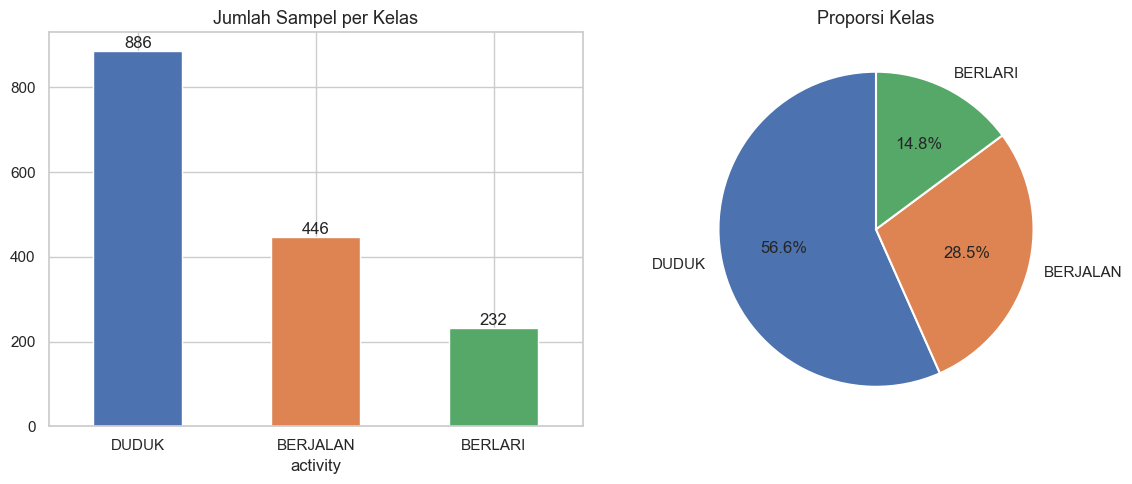

In [4]:
dist = class_distribution(df)
print('=== DISTRIBUSI KELAS ===')
print(dist.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
dist['count'].plot(kind='bar', ax=axes[0], color=COLORS, edgecolor='white', rot=0)
axes[0].set_title('Jumlah Sampel per Kelas', fontsize=13)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}',
                     (bar.get_x()+bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom')
axes[1].pie(dist['count'], labels=dist.index, colors=COLORS, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Proporsi Kelas', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/distribusi_kelas.png', dpi=150)
plt.show()

## 4. Distribusi Ketiga Fitur per Kelas (Accel + Gyro + BPM)

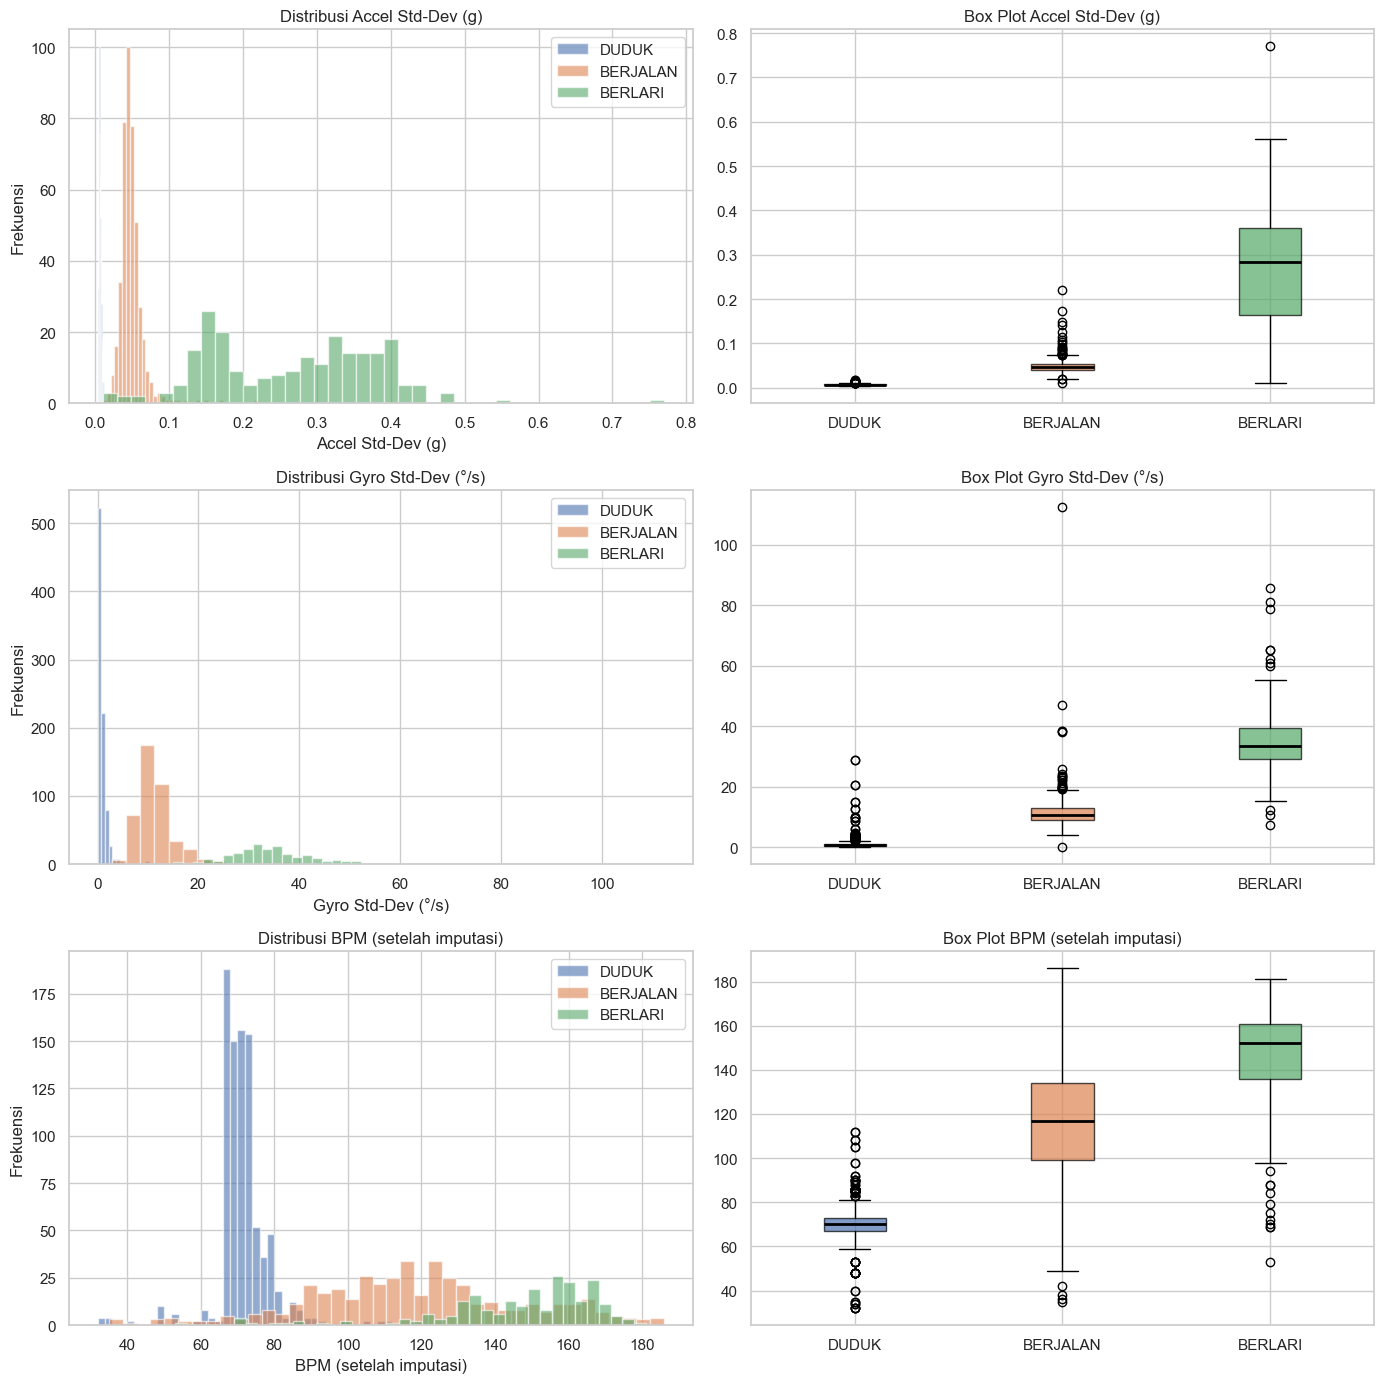

In [5]:
feat_labels = {
    'accel_stddev': 'Accel Std-Dev (g)',
    'gyro_stddev':  'Gyro Std-Dev (°/s)',
    'bpm_filled':   'BPM (setelah imputasi)'
}

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
color_map = dict(zip(CLASSES, COLORS))

for row_idx, feat in enumerate(['accel_stddev', 'gyro_stddev', 'bpm_filled']):
    label = feat_labels[feat]
    # Histogram
    ax = axes[row_idx][0]
    for cls in CLASSES:
        subset = df[df[TARGET]==cls][feat]
        ax.hist(subset, bins=40, alpha=0.6, color=color_map[cls], label=cls)
    ax.set_title(f'Distribusi {label}', fontsize=12)
    ax.set_xlabel(label); ax.set_ylabel('Frekuensi'); ax.legend()
    # Box plot
    ax2 = axes[row_idx][1]
    data_per = [df[df[TARGET]==cls][feat].values for cls in CLASSES]
    bp = ax2.boxplot(data_per, patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax2.set_xticks(range(1, len(CLASSES)+1)); ax2.set_xticklabels(CLASSES)
    ax2.set_title(f'Box Plot {label}', fontsize=12)

plt.tight_layout()
plt.savefig('../data/processed/distribusi_3fitur.png', dpi=150)
plt.show()

## 5. Scatter Matrix 3D — Separabilitas Kelas

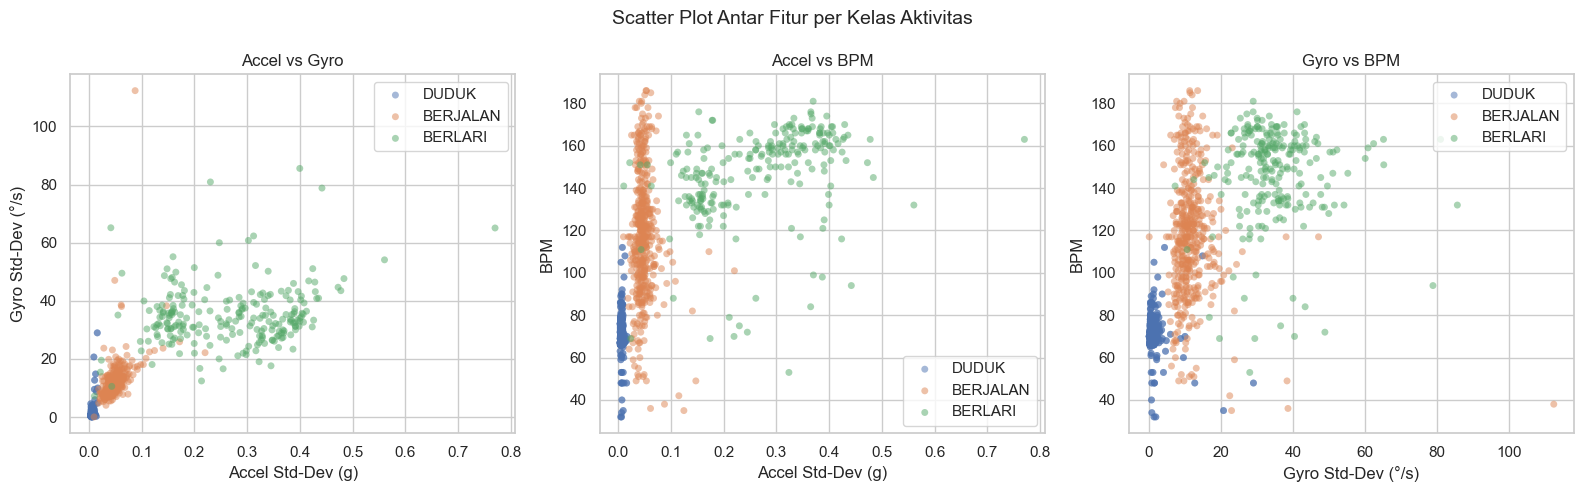

In [6]:
fig = plt.figure(figsize=(16, 5))

# Plot 1: Accel vs Gyro
ax1 = fig.add_subplot(131)
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]
    ax1.scatter(s['accel_stddev'], s['gyro_stddev'],
                c=color, label=cls, alpha=0.5, s=25, edgecolors='none')
ax1.set_xlabel('Accel Std-Dev (g)'); ax1.set_ylabel('Gyro Std-Dev (°/s)')
ax1.set_title('Accel vs Gyro'); ax1.legend()

# Plot 2: Accel vs BPM
ax2 = fig.add_subplot(132)
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]
    ax2.scatter(s['accel_stddev'], s['bpm_filled'],
                c=color, label=cls, alpha=0.5, s=25, edgecolors='none')
ax2.set_xlabel('Accel Std-Dev (g)'); ax2.set_ylabel('BPM')
ax2.set_title('Accel vs BPM'); ax2.legend()

# Plot 3: Gyro vs BPM
ax3 = fig.add_subplot(133)
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]
    ax3.scatter(s['gyro_stddev'], s['bpm_filled'],
                c=color, label=cls, alpha=0.5, s=25, edgecolors='none')
ax3.set_xlabel('Gyro Std-Dev (°/s)'); ax3.set_ylabel('BPM')
ax3.set_title('Gyro vs BPM'); ax3.legend()

plt.suptitle('Scatter Plot Antar Fitur per Kelas Aktivitas', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/scatter_3fitur.png', dpi=150)
plt.show()

## 6. Statistik Per Kelas — Panduan Tuning Threshold ESP32

In [7]:
print('=== STATISTIK PER KELAS ===')
for feat, label in feat_labels.items():
    print(f'\n  {feat} ({label}):')
    for cls in CLASSES:
        s = df[df[TARGET]==cls][feat]
        print(f'    {cls:<10}: mean={s.mean():.4f}  std={s.std():.4f}  '
              f'p5={s.quantile(0.05):.4f}  p95={s.quantile(0.95):.4f}')

=== STATISTIK PER KELAS ===

  accel_stddev (Accel Std-Dev (g)):
    DUDUK     : mean=0.0067  std=0.0019  p5=0.0044  p95=0.0104
    BERJALAN  : mean=0.0487  std=0.0180  p5=0.0301  p95=0.0729
    BERLARI   : mean=0.2681  std=0.1130  p5=0.1139  p95=0.4241

  gyro_stddev (Gyro Std-Dev (°/s)):
    DUDUK     : mean=1.1099  std=2.1021  p5=0.2711  p95=2.5974
    BERJALAN  : mean=11.8410  std=6.4988  p5=7.0941  p95=18.7750
    BERLARI   : mean=34.9100  std=10.4748  p5=21.2921  p95=51.2196

  bpm_filled (BPM (setelah imputasi)):
    DUDUK     : mean=70.7381  std=7.5572  p5=66.0000  p95=81.0000
    BERJALAN  : mean=118.1300  std=29.2857  p5=69.5000  p95=167.7500
    BERLARI   : mean=146.6767  std=22.0600  p5=98.5500  p95=170.0000


## 7. Analisis BPM — Distribusi Valid vs Imputasi

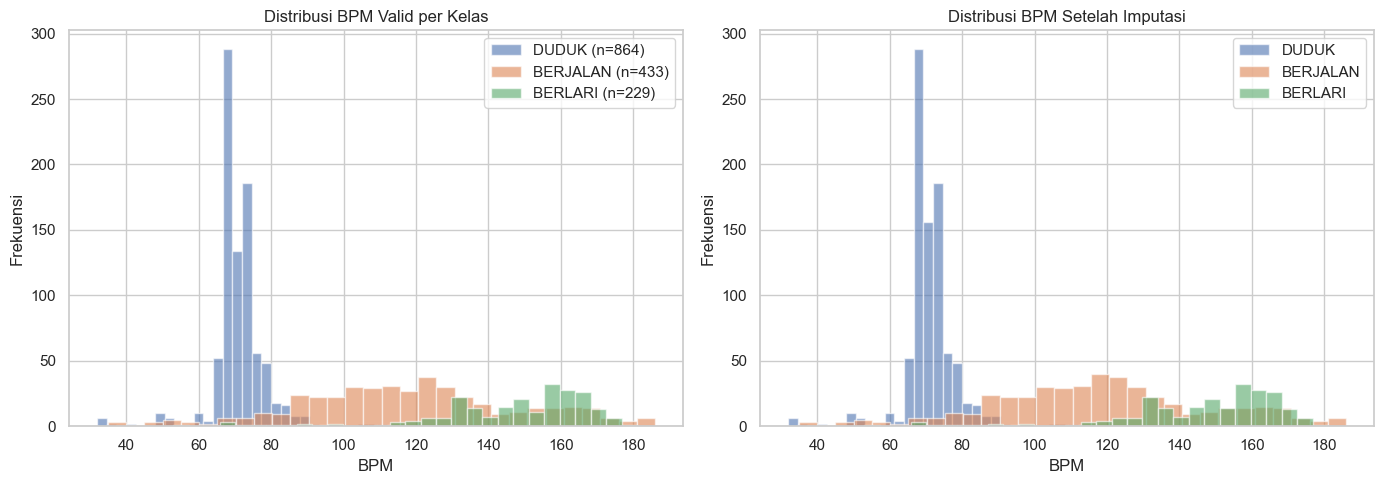


=== % BPM Valid per Kelas ===
  DUDUK     :  864/ 886 (97.5% valid)
  BERJALAN  :  433/ 446 (97.1% valid)
  BERLARI   :  229/ 232 (98.7% valid)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BPM valid saja per kelas
ax = axes[0]
for cls, color in zip(CLASSES, COLORS):
    valid = df_raw[(df_raw[TARGET]==cls) & (df_raw['bpm']>0)]['bpm']
    ax.hist(valid, bins=30, alpha=0.6, color=color, label=f'{cls} (n={len(valid)})')
ax.set_title('Distribusi BPM Valid per Kelas', fontsize=12)
ax.set_xlabel('BPM'); ax.set_ylabel('Frekuensi'); ax.legend()

# BPM setelah imputasi per kelas
ax2 = axes[1]
for cls, color in zip(CLASSES, COLORS):
    s = df[df[TARGET]==cls]['bpm_filled']
    ax2.hist(s, bins=30, alpha=0.6, color=color, label=cls)
ax2.set_title('Distribusi BPM Setelah Imputasi', fontsize=12)
ax2.set_xlabel('BPM'); ax2.set_ylabel('Frekuensi'); ax2.legend()

plt.tight_layout()
plt.savefig('../data/processed/bpm_distribusi.png', dpi=150)
plt.show()

# Persentase BPM valid
print('\n=== % BPM Valid per Kelas ===')
for cls in CLASSES:
    total = len(df_raw[df_raw[TARGET]==cls])
    valid = len(df_raw[(df_raw[TARGET]==cls)&(df_raw['bpm']>0)])
    print(f'  {cls:<10}: {valid:4d}/{total:4d} ({valid/total*100:.1f}% valid)')

## 8. Deteksi Outlier & Simpan Dataset Bersih

In [9]:
from utils import remove_outliers
df_clean = remove_outliers(df)
print(f'Sebelum remove outlier: {len(df)}')
print(f'Sesudah remove outlier: {len(df_clean)}')
print(f'Dihapus: {len(df)-len(df_clean)} baris')

clean_path = '../data/processed/dataset_clean.csv'
df_clean.to_csv(clean_path, index=False)
print(f'\n✅ Dataset bersih disimpan → {clean_path}')
print(f'   Shape: {df_clean.shape}')

Sebelum remove outlier: 1564
Sesudah remove outlier: 1541
Dihapus: 23 baris

✅ Dataset bersih disimpan → ../data/processed/dataset_clean.csv
   Shape: (1541, 7)


## 9. Korelasi Fitur

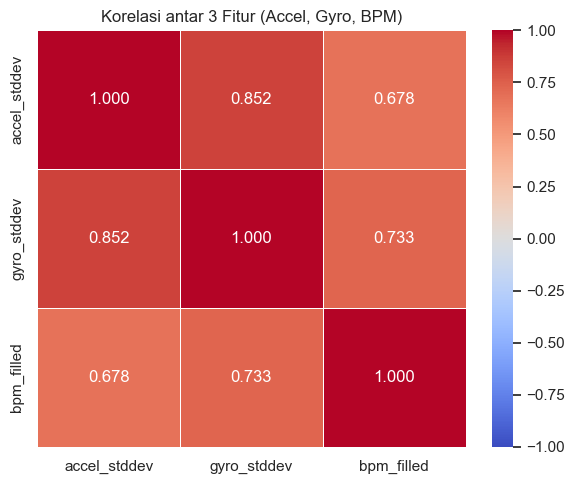

In [10]:
corr_cols = ['accel_stddev','gyro_stddev','bpm_filled']
corr = df_clean[corr_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Korelasi antar 3 Fitur (Accel, Gyro, BPM)')
plt.tight_layout()
plt.savefig('../data/processed/korelasi_3fitur.png', dpi=150)
plt.show()